# Week 3 Jupyter Notebook
## Linear Regression 3

### Marketing Conversion Propensity Project

The goal of this project is to analyze marketing and product performance data and identify which variables are associated with higher conversion outcomes.

For Week 3, this notebook applies linear regression concepts including forward selection, backward selection, Principal Component Regression (PCR), and Partial Least Squares Regression (PLSR).

The target variable for this analysis is Conversions.

In [92]:
%pip install scikit-learn


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_squared_error, r2_score

In [94]:
df = pd.read_csv("marketing_and_product_performance.csv")

df.head()

,Campaign_ID,Product_ID,Budget,Clicks,Conversions,Revenue_Generated,ROI,Customer_ID,Subscription_Tier,Subscription_Length,Flash_Sale_ID,Discount_Level,Units_Sold,Bundle_ID,Bundle_Price,Customer_Satisfaction_Post_Refund,Common_Keywords
0,CMP_RLSDVN,PROD_HBJFA3,41770.45,4946,73,15520.09,1.94,CUST_1K7G39,Premium,4,FLASH_1VFK5K,43,34,BNDL_29U6W5,433.80,4,Affordable
1,CMP_JHHUE9,PROD_OE8YNJ,29900.93,570,510,30866.17,0.76,CUST_0DWS6F,Premium,4,FLASH_1M6COK,28,97,BNDL_ULV60J,289.29,2,Innovative
2,CMP_6SBOWN,PROD_4V8A08,22367.45,3546,265,32585.62,1.41,CUST_BR2GST,Basic,9,FLASH_J4PEON,51,160,BNDL_0HY0EF,462.87,4,Affordable
3,CMP_Q31QCU,PROD_A1Q6ZB,29957.54,2573,781,95740.12,3.32,CUST_6TBY6K,Premium,32,FLASH_1TOVXT,36,159,BNDL_AI09BC,334.16,1,Durable
4,CMP_AY0UTJ,PROD_F57N66,36277.19,818,79,81990.43,3.53,CUST_XASI45,Standard,29,FLASH_AOBHXL,20,52,BNDL_R03ITT,371.67,2,Affordable


In [95]:
print("Dataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns)

print("\nDataset information:")
df.info()

Dataset shape:
(10000, 17)

Column names:
Index(['Campaign_ID', 'Product_ID', 'Budget', 'Clicks', 'Conversions',
       'Revenue_Generated', 'ROI', 'Customer_ID', 'Subscription_Tier',
       'Subscription_Length', 'Flash_Sale_ID', 'Discount_Level', 'Units_Sold',
       'Bundle_ID', 'Bundle_Price', 'Customer_Satisfaction_Post_Refund',
       'Common_Keywords'],
      dtype='str')

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Campaign_ID                        10000 non-null  str    
 1   Product_ID                         10000 non-null  str    
 2   Budget                             10000 non-null  float64
 3   Clicks                             10000 non-null  int64  
 4   Conversions                        10000 non-null  int64  
 5   Revenue_Generated                  10000 non-n

In [96]:
df.isnull().sum()

Campaign_ID                          0
Product_ID                           0
Budget                               0
Clicks                               0
Conversions                          0
Revenue_Generated                    0
ROI                                  0
Customer_ID                          0
Subscription_Tier                    0
Subscription_Length                  0
Flash_Sale_ID                        0
Discount_Level                       0
Units_Sold                           0
Bundle_ID                            0
Bundle_Price                         0
Customer_Satisfaction_Post_Refund    0
Common_Keywords                      0
dtype: int64

In [97]:
df = df.dropna()

In [98]:
features = [
    "Budget",
    "Clicks",
    "Revenue_Generated",
    "ROI",
    "Subscription_Length",
    "Discount_Level",
    "Units_Sold",
    "Bundle_Price",
    "Customer_Satisfaction_Post_Refund"
]

X = df[features]
y = df["Conversions"]

In [99]:
# Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [100]:
# Feature scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [101]:
# Baseline linear regression model

baseline_model = LinearRegression()

baseline_model.fit(X_train_scaled, y_train)

baseline_pred = baseline_model.predict(X_test_scaled)

baseline_r2 = r2_score(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))

print("Baseline Linear Regression R2:", baseline_r2)
print("Baseline Linear Regression RMSE:", baseline_rmse)

Baseline Linear Regression R2: -0.0002424309712767414
Baseline Linear Regression RMSE: 290.9955380443076


In [102]:
# Forward selection

forward_selector = SequentialFeatureSelector(
    LinearRegression(),
    n_features_to_select=5,
    direction="forward"
)

forward_selector.fit(X_train_scaled, y_train)

forward_features = X.columns[forward_selector.get_support()]

print("Forward Selected Features:")
print(forward_features)

Forward Selected Features:
Index(['Budget', 'Clicks', 'Discount_Level', 'Units_Sold',
       'Customer_Satisfaction_Post_Refund'],
      dtype='str')


In [103]:
# Forward selection model

X_train_forward = forward_selector.transform(X_train_scaled)
X_test_forward = forward_selector.transform(X_test_scaled)

forward_model = LinearRegression()

forward_model.fit(X_train_forward, y_train)

forward_pred = forward_model.predict(X_test_forward)

forward_r2 = r2_score(y_test, forward_pred)
forward_rmse = np.sqrt(mean_squared_error(y_test, forward_pred))

print("Forward Selection R2:", forward_r2)
print("Forward Selection RMSE:", forward_rmse)

Forward Selection R2: -0.0025068674882726683
Forward Selection RMSE: 291.32474243602934


In [104]:
# Backward selection

backward_selector = SequentialFeatureSelector(
    LinearRegression(),
    n_features_to_select=5,
    direction="backward"
)

backward_selector.fit(X_train_scaled, y_train)

backward_features = X.columns[backward_selector.get_support()]

print("Backward Selected Features:")
print(backward_features)

Backward Selected Features:
Index(['Budget', 'Clicks', 'Discount_Level', 'Units_Sold',
       'Customer_Satisfaction_Post_Refund'],
      dtype='str')


In [105]:
# Backward selection model

X_train_backward = backward_selector.transform(X_train_scaled)
X_test_backward = backward_selector.transform(X_test_scaled)

backward_model = LinearRegression()

backward_model.fit(X_train_backward, y_train)

backward_pred = backward_model.predict(X_test_backward)

backward_r2 = r2_score(y_test, backward_pred)
backward_rmse = np.sqrt(mean_squared_error(y_test, backward_pred))

print("Backward Selection R2:", backward_r2)
print("Backward Selection RMSE:", backward_rmse)

Backward Selection R2: -0.0025068674882726683
Backward Selection RMSE: 291.32474243602934


In [106]:
# Principal Component Regression

pca = PCA(n_components=5)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

pcr_model = LinearRegression()

pcr_model.fit(X_train_pca, y_train)

pcr_pred = pcr_model.predict(X_test_pca)

pcr_r2 = r2_score(y_test, pcr_pred)
pcr_rmse = np.sqrt(mean_squared_error(y_test, pcr_pred))

print("PCR R2:", pcr_r2)
print("PCR RMSE:", pcr_rmse)

print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

PCR R2: 0.0011226492831485357
PCR RMSE: 290.7969022566272
Explained Variance Ratio:
[0.11694151 0.11571427 0.11269269 0.11227661 0.11104578]


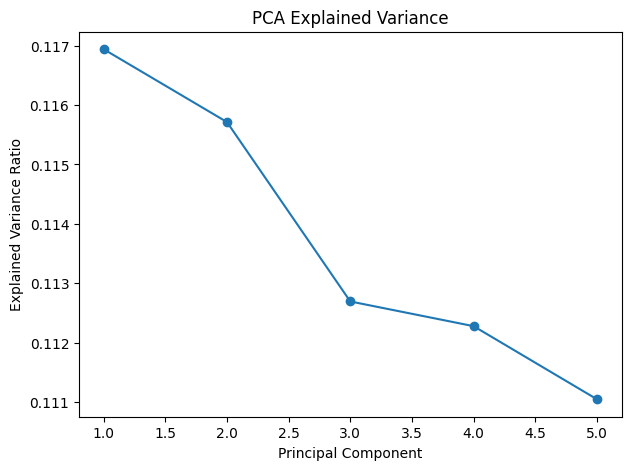

In [107]:
# Plot PCA explained variance

plt.figure(figsize=(7,5))

plt.plot(
    range(1, len(pca.explained_variance_ratio_) + 1),
    pca.explained_variance_ratio_,
    marker="o"
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("PCA Explained Variance")
plt.show()

In [108]:
# Partial Least Squares Regression

pls = PLSRegression(n_components=5)

pls.fit(X_train_scaled, y_train)

pls_pred = pls.predict(X_test_scaled)

pls_r2 = r2_score(y_test, pls_pred)
pls_rmse = np.sqrt(mean_squared_error(y_test, pls_pred))

print("PLSR R2:", pls_r2)
print("PLSR RMSE:", pls_rmse)

PLSR R2: -0.00024243097904674826
PLSR RMSE: 290.99553804543785


In [109]:
# Compare model performance

results = pd.DataFrame({
    "Model": [
        "Baseline Linear Regression",
        "Forward Selection",
        "Backward Selection",
        "PCR",
        "PLSR"
    ],
    "R2 Score": [
        baseline_r2,
        forward_r2,
        backward_r2,
        pcr_r2,
        pls_r2
    ],
    "RMSE": [
        baseline_rmse,
        forward_rmse,
        backward_rmse,
        pcr_rmse,
        pls_rmse
    ]
})

results

,Model,R2 Score,RMSE
0,Baseline Linear Regression,-0.000242,290.995538
1,Forward Selection,-0.002507,291.324742
2,Backward Selection,-0.002507,291.324742
3,PCR,0.001123,290.796902
4,PLSR,-0.000242,290.995538


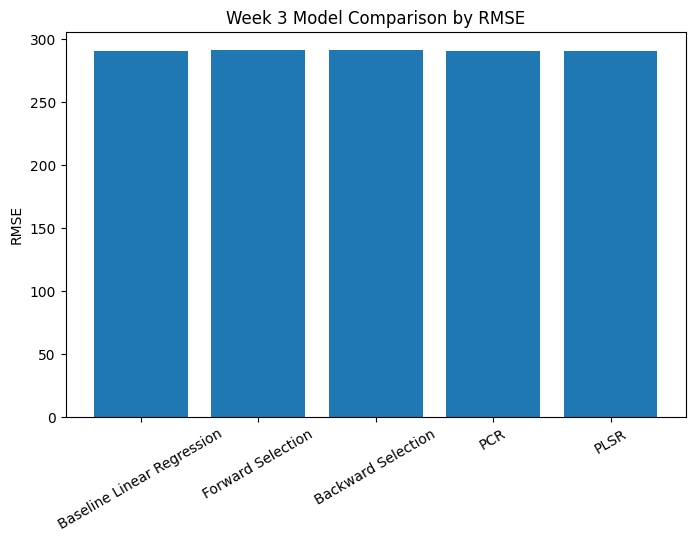

In [110]:
# Plot RMSE comparison

plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["RMSE"])

plt.ylabel("RMSE")
plt.title("Week 3 Model Comparison by RMSE")
plt.xticks(rotation=30)

plt.show()

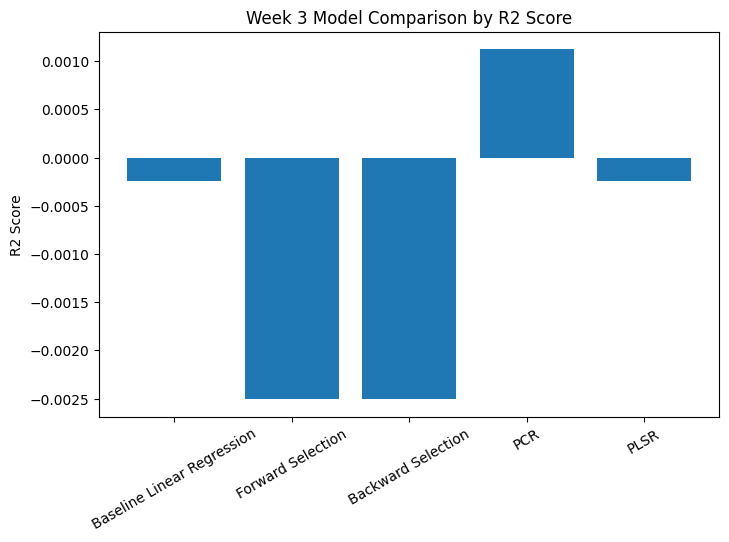

In [111]:
# Plot R2 comparison

plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["R2 Score"])

plt.ylabel("R2 Score")
plt.title("Week 3 Model Comparison by R2 Score")
plt.xticks(rotation=30)

plt.show()

# Conclusion

This Week 3 notebook applied forward selection, backward selection, Principal Component Regression, and Partial Least Squares Regression to the Marketing Conversion Propensity dataset.

The target variable was Conversions, and the predictor variables included Budget, Clicks, Revenue_Generated, ROI, Subscription_Length, Discount_Level, Units_Sold, Bundle_Price, and Customer_Satisfaction_Post_Refund.

Forward selection and backward selection were used to identify smaller groups of useful predictor variables. These methods help simplify the model by selecting the features that contribute most to prediction performance.

Principal Component Regression was used to reduce the predictor variables into a smaller number of principal components before fitting a regression model. This helps address multicollinearity and simplifies the feature space.

Partial Least Squares Regression was also applied because it reduces dimensionality while considering the relationship between predictors and the target variable.

The models were compared using R2 Score and RMSE. R2 shows how much variation in conversions is explained by the model, while RMSE shows the average prediction error.

Overall, this analysis supports the capstone project by showing how feature selection and dimensionality reduction techniques can be used to improve the interpretation and prediction of marketing conversion outcomes.